In [6]:
import pandas as pd
import numpy as np

DATA_FILE = '../data/scenario_6_marina_features_50ms_final.csv'
df = pd.read_csv(DATA_FILE)

df.sort_values(['video_id', 'iteration', 'timestamp'], inplace=True)

print("Generating Advanced Network Features...")

#we don't calculate trends across different video sessions
g = df.groupby(['video_id', 'iteration'])

# Exponential Moving Averages (EMA) 
# Simulates the switch keeping a 'running average' state
# span=20 roughly equals 1 second of history (20 * 50ms)
df['bw_ema'] = g['bwe'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
df['jitter_ema'] = g['jitter'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
df['iat_ema'] = g['iat_sum'].transform(lambda x: x.ewm(span=20, adjust=False).mean())

#  Lag Features (What happened 50ms ago?)
cols_to_lag = ['bwe', 'jitter', 'packet_count']
for col in cols_to_lag:
    df[f'{col}_prev'] = g[col].shift(1) # 1 step back

#Rate of Change (Acceleration) 
# Is bandwidth dropping fast?
df['bw_change'] = df['bwe'] - df['bwe_prev']

df.dropna(inplace=True)

print(f"Feature Engineering Complete. Final Shape: {df.shape}")
df.head()

Generating Advanced Network Features...
Feature Engineering Complete. Final Shape: (163039, 20)


,timestamp,packet_count,ps_sum,ps2_sum,ps3_sum,iat_sum,iat2_sum,iat3_sum,jitter,buffer_level_ms,bwe,video_id,iteration,bw_ema,jitter_ema,iat_ema,bwe_prev,jitter_prev,packet_count_prev,bw_change
1,1517451593950,73,67845,91262479,125607724845,50.209046,59.186920,97.430733,0.674682,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.593326,50.108523,11491117.0,0.584762,82.0,0.0
2,1517451594000,69,66253,89348217,122989949167,50.037145,54.620074,72.432084,0.694607,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.602972,50.101725,11491117.0,0.674682,73.0,0.0
3,1517451594050,71,66387,89357195,122990550693,49.897909,64.854621,116.702641,0.712479,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.613401,50.082314,11491117.0,0.694607,69.0,0.0
4,1517451594100,71,66387,89357195,122990550693,48.899889,53.711902,72.957715,0.648478,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.616742,49.969702,11491117.0,0.712479,71.0,0.0
5,1517451594900,72,67765,91256079,125607212845,50.486087,52.013690,66.979565,0.613309,11729,11491117,Vid_2d1VrCvdzbY,Iteration_1,11491117.0,0.616415,50.018882,11491117.0,0.648478,71.0,0.0


In [7]:
LOOKAHEAD_STEPS = 10       # Look 500ms into the future
CRITICAL_BUFFER_MS = 2000  # If buffer is < 2 seconds, we are in danger
DROP_THRESHOLD = -200      # Buffer dropping by > 100ms

# Calculate future slope
df['future_buffer'] = df.groupby(['video_id', 'iteration'])['buffer_level_ms'].shift(-LOOKAHEAD_STEPS)
df['buffer_slope'] = df['future_buffer'] - df['buffer_level_ms']

df.dropna(subset=['future_buffer'], inplace=True)

conditions = [
    # 1. CRITICAL: Buffer is dropping AND we are already low (<2s)
    (df['buffer_slope'] < DROP_THRESHOLD) & (df['buffer_level_ms'] < CRITICAL_BUFFER_MS),
    
    # 2. WARNING: Buffer is dropping, but we have reserve (>2s)
    (df['buffer_slope'] < DROP_THRESHOLD) & (df['buffer_level_ms'] >= CRITICAL_BUFFER_MS),
]

# Choices: 
# Critical = Immediate action needed (Switch should prioritize this traffic)
# Safe_Drain = Monitor, but no panic
# Steady = Everything is fine
choices = ['Critical', 'Safe_Drain']
df['qoe_state'] = np.select(conditions, choices, default='Steady')

print("Target Class Distribution:")
print(df['qoe_state'].value_counts(normalize=True))

Target Class Distribution:
qoe_state
Safe_Drain    0.612900
Steady        0.386633
Critical      0.000468
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


features = [
    # Instant values
    'packet_count', 'ps_sum', 'iat_sum', 
    #'bwe',
    'jitter',
    # Historical Context 
    #'bw_ema',
    #'jitter_ema', 'iat_ema',
    #'bwe_prev', 
    #'jitter_prev',
    #'bw_change'
]

X = df[features]
y = df['qoe_state']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Training Random Forest...

--- Classification Report ---
              precision    recall  f1-score   support

    Critical       0.00      0.95      0.00        19
  Safe_Drain       0.78      0.02      0.03     24904
      Steady       0.69      0.69      0.69     15710

    accuracy                           0.28     40633
   macro avg       0.49      0.55      0.24     40633
weighted avg       0.74      0.28      0.29     40633



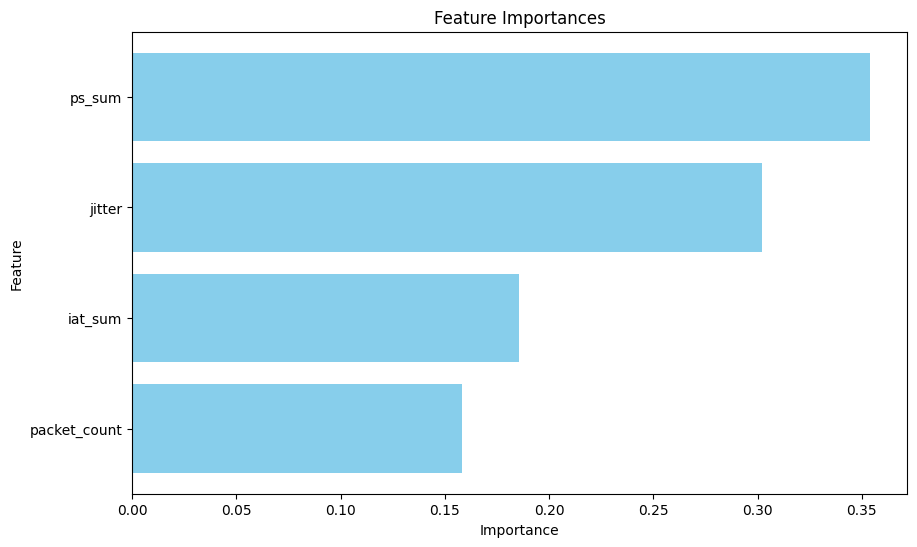

        Feature  Importance
1        ps_sum    0.354078
3        jitter    0.302006
2       iat_sum    0.185730
0  packet_count    0.158185


In [ ]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

print(feature_importances)

In [10]:

np.save('np_data.npy', X.to_numpy())

y_dummies = pd.get_dummies(y)
np.save('np_dummies.npy', y_dummies.to_numpy())

print("Files 'np_data.npy' and 'np_dummies.npy' have been created.")

Files 'np_data.npy' and 'np_dummies.npy' have been created.


The initial phase of the research focused on establishing a baseline classification model using "Marina-style" statistical features, where packet sizes and inter-arrival times were aggregated into isolated 50ms time windows using sums and statistical moments (squares and cubes). This earlier approach treated every time window as an independent event, relying on a simplistic labeling strategy that categorized network states solely based on the slope of buffer changes (filling versus depleting) without regard for the absolute buffer level. While this established a foundational correlation between traffic volume and buffer trends, the model lacked temporal context, meaning it could not distinguish between a sudden traffic drop and a sustained outage, nor could it differentiate between a benign buffer drop from a high level and a critical depletion event leading to a video stall.
In the updated ipynbb,  restructured the feature engineering part to add temporal awareness and stateful logic suitable for network switches. The methodology moved beyond isolated snapshots by generating "Lag" features (representing the immediate history of the previous windows) and Exponential Moving Averages (EMA), which capture the velocity and acceleration of network throughput and jitter over a one-second horizon. Furthermore, the target labeling system was changed from a binary slope detection to a risk-based classification scheme. This new logic introduced a "Critical" class—defined as a depleting trend occurring when the buffer is already below a safety threshold (e.g., 2 seconds)—thereby forcing the Random Forest model to prioritize the detection of imminent QoE violations rather than simple fluctuations. This shift transitioned the system from a stateless traffic analyzer to a predictive, risk-aware QoE monitor capable of handling class imbalances through weighted training parameters.



https://conferences.sigcomm.org/co-next/2012/eproceedings/conext/p97.pdf
analyzes bandwidth estimation techniques. While they propose harmonic means for stability, they extensively discuss and compare against EWMA-based estimators used in commercial players.
#####
===>raw throughput is too volatile to correlate directly with buffer health. Instead, smoothed estimates like EWMA provide a more reliable indicator of network conditions affecting QoE.

## TODO Implement a graph/excalidraw/diagram showing the difference between isolated window features vs lagged features and EMA features.
Lag feature
Our previous model looks at a single 50ms window in isolation. However, the Buffer Level is cumulative. If the throughput was low 1 second ago, the buffer is likely suffering now, even if the current 50ms window looks fine.

Capture "ON/OFF" Burst Patterns
The Problem: Video traffic is not constant; it comes in bursts (ON periods) followed by silence (OFF periods).

Maybe Create features that specifically measure the "Silence"?

## Use "Rolling" Statistics (Trend Analysis)
50ms is noisy. One dropped packet causes a spike in Jitter that might not mean anything.
Exponential Moving Averages (EMA). Switches can calculate EMA efficiently because it only requires storing the previous value.
EMA_t = α * X_t + (1 - α) * EMA_(t-1)
Where:
- EMA_t is the current EMA value.
- X_t is the current observation.
- α is the smoothing factor (0 < α ≤ 1), which determines how much weight is given to the most recent observation versus the historical EMA.
By incorporating EMA features for Throughput and Jitter over a 1-second horizon, the model can better capture underlying trends rather than reacting to transient spikes or drops.


These two variables have been calcucalted in the control plane rather than the data plane, as they require division operations which are more computationally expensive. However, they could be approximated in the data plane using fixed-point arithmetic or lookup tables if necessary for real-time processing.